# 03 – Forecasting Models: Day-Ahead Forecasts

Dieses Notebook erzeugt die Forecasts für die spätere Bidding-Evaluation.

## Ziel

Wir trainieren verschiedene Forecasting-Modelle im **Day-Ahead-Setup**.  
Für die Prognose der Produktion zum Zeitpunkt \(t\) werden nur Informationen verwendet, die mindestens 24 Stunden vorher bekannt wären.

## Wichtig

Dieses Notebook bewertet die Modelle **nicht final über RMSE**.  
RMSE, MAE und Pinball Loss dienen nur zur deskriptiven Einordnung.

Der zentrale Vergleich erfolgt später in Notebook 04 über:

```text
Forecast → Bid → Profit / Newsvendor Loss
```

## Modellgruppen

### Point Forecasts
- Persistence 24h
- Elastic Net
- Random Forest
- Gradient Boosting

### Probabilistic Forecasts
- Quantile Regression
- Quantile Regression Forest (QRF)
- Quantile Gradient Boosting
- Quantile Neural Network


## 1. Setup und Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"

RESULTS_DIR = PROJECT_ROOT / "results"
FORECAST_DIR = RESULTS_DIR / "forecasts"
MODELS_DIR = RESULTS_DIR / "models"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

for directory in [FORECAST_DIR, MODELS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)


Project root: /Users/noahweis/wind_bidding_project
Data path: /Users/noahweis/wind_bidding_project/data/processed/final_dataset.csv


## 2. Modell-Imports aus `src.models`

In [2]:
from src.models import (
    elastic_net,
    random_forest,
    gradient_boosting,
    quantile_regression,
    quantile_regression_forest,
    quantile_gradient_boosting,
    quantile_neural_network,
)


## 3. Daten laden

Erwartete Eingabedatei:

```text
data/processed/final_dataset.csv
```

Mindestens benötigte Spalten:

```text
timestamp
power
```

Optional:

```text
wind_speed
```


In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Shape:", df.shape)
df.head()


Shape: (6600, 10)


,timestamp,power,wind_speed,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos
0,2016-03-31 11:00:00,-11.000000,2.566667,11,3,3,2.588190e-01,-0.965926,0.433884,-0.900969
1,2016-03-31 12:00:00,-7.666667,3.616667,12,3,3,1.224647e-16,-1.000000,0.433884,-0.900969
2,2016-03-31 13:00:00,30.666667,3.533333,13,3,3,-2.588190e-01,-0.965926,0.433884,-0.900969
3,2016-03-31 14:00:00,169.833333,4.783333,14,3,3,-5.000000e-01,-0.866025,0.433884,-0.900969
4,2016-03-31 15:00:00,45.000000,0.800000,15,3,3,-7.071068e-01,-0.707107,0.433884,-0.900969


## 4. Day-Ahead Feature Engineering

Für die spätere ökonomische Bewertung wird die Zielvariable in **MWh** verwendet.

Falls `power` in kW vorliegt und die Daten stündlich aggregiert sind:

\[
energy\_mwh_t = \frac{\max(power_t, 0)}{1000}
\]

Die direkte Zielstunden-Windgeschwindigkeit `wind_speed` wird **nicht** direkt als Feature genutzt.  
Stattdessen werden nur historische Lag-Werte verwendet.


In [4]:
df_model = df.copy()

df_model["energy_mwh"] = df_model["power"].clip(lower=0) / 1000

df_model["hour"] = df_model["timestamp"].dt.hour
df_model["dayofweek"] = df_model["timestamp"].dt.dayofweek
df_model["month"] = df_model["timestamp"].dt.month

df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

df_model["dow_sin"] = np.sin(2 * np.pi * df_model["dayofweek"] / 7)
df_model["dow_cos"] = np.cos(2 * np.pi * df_model["dayofweek"] / 7)

for lag in [24, 48, 72, 168]:
    df_model[f"energy_lag_{lag}"] = df_model["energy_mwh"].shift(lag)

if "wind_speed" in df_model.columns:
    for lag in [24, 48, 72, 168]:
        df_model[f"wind_speed_lag_{lag}"] = df_model["wind_speed"].shift(lag)
else:
    warnings.warn("Spalte 'wind_speed' nicht gefunden. Wind-Lag-Features werden übersprungen.")

df_model["energy_roll_mean_24"] = df_model["energy_mwh"].shift(24).rolling(24).mean()
df_model["energy_roll_std_24"] = df_model["energy_mwh"].shift(24).rolling(24).std()
df_model["energy_roll_mean_168"] = df_model["energy_mwh"].shift(24).rolling(168).mean()
df_model["energy_roll_std_168"] = df_model["energy_mwh"].shift(24).rolling(168).std()

if "wind_speed" in df_model.columns:
    df_model["wind_roll_mean_24"] = df_model["wind_speed"].shift(24).rolling(24).mean()
    df_model["wind_roll_std_24"] = df_model["wind_speed"].shift(24).rolling(24).std()
    df_model["wind_roll_mean_168"] = df_model["wind_speed"].shift(24).rolling(168).mean()
    df_model["wind_roll_std_168"] = df_model["wind_speed"].shift(24).rolling(168).std()

df_model.head()


,timestamp,power,wind_speed,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos,...,wind_speed_lag_72,wind_speed_lag_168,energy_roll_mean_24,energy_roll_std_24,energy_roll_mean_168,energy_roll_std_168,wind_roll_mean_24,wind_roll_std_24,wind_roll_mean_168,wind_roll_std_168
0,2016-03-31 11:00:00,-11.000000,2.566667,11,3,3,2.588190e-01,-0.965926,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-03-31 12:00:00,-7.666667,3.616667,12,3,3,1.224647e-16,-1.000000,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-03-31 13:00:00,30.666667,3.533333,13,3,3,-2.588190e-01,-0.965926,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-03-31 14:00:00,169.833333,4.783333,14,3,3,-5.000000e-01,-0.866025,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-03-31 15:00:00,45.000000,0.800000,15,3,3,-7.071068e-01,-0.707107,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Feature-Set und Zielvariable

In [5]:
BASE_FEATURES = [
    "energy_lag_24",
    "energy_lag_48",
    "energy_lag_72",
    "energy_lag_168",
    "energy_roll_mean_24",
    "energy_roll_std_24",
    "energy_roll_mean_168",
    "energy_roll_std_168",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month",
]

WIND_LAG_FEATURES = [
    "wind_speed_lag_24",
    "wind_speed_lag_48",
    "wind_speed_lag_72",
    "wind_speed_lag_168",
    "wind_roll_mean_24",
    "wind_roll_std_24",
    "wind_roll_mean_168",
    "wind_roll_std_168",
]

FEATURES_DAY_AHEAD = BASE_FEATURES + [
    feature for feature in WIND_LAG_FEATURES if feature in df_model.columns
]

TARGET = "energy_mwh"

df_model = df_model.dropna(subset=FEATURES_DAY_AHEAD + [TARGET]).reset_index(drop=True)

X = df_model[FEATURES_DAY_AHEAD]
y = df_model[TARGET]

print("Number of observations:", len(df_model))
print("Number of features:", len(FEATURES_DAY_AHEAD))
print("Features:")
for feature in FEATURES_DAY_AHEAD:
    print("-", feature)

X.head()


Number of observations: 6409
Number of features: 21
Features:
- energy_lag_24
- energy_lag_48
- energy_lag_72
- energy_lag_168
- energy_roll_mean_24
- energy_roll_std_24
- energy_roll_mean_168
- energy_roll_std_168
- hour_sin
- hour_cos
- dow_sin
- dow_cos
- month
- wind_speed_lag_24
- wind_speed_lag_48
- wind_speed_lag_72
- wind_speed_lag_168
- wind_roll_mean_24
- wind_roll_std_24
- wind_roll_mean_168
- wind_roll_std_168


,energy_lag_24,energy_lag_48,energy_lag_72,energy_lag_168,energy_roll_mean_24,energy_roll_std_24,energy_roll_mean_168,energy_roll_std_168,hour_sin,hour_cos,...,dow_cos,month,wind_speed_lag_24,wind_speed_lag_48,wind_speed_lag_72,wind_speed_lag_168,wind_roll_mean_24,wind_roll_std_24,wind_roll_mean_168,wind_roll_std_168
0,0.093500,0.000000,0.000000,0.311500,0.072257,0.154379,0.015471,0.071400,5.000000e-01,-0.866025,...,-0.900969,4,5.150000,4.833333,2.216667,8.800000,5.714583,1.104419,3.511607,1.931382
1,0.318000,0.000000,0.000000,0.298667,0.085507,0.161395,0.017364,0.075106,2.588190e-01,-0.965926,...,-0.900969,4,5.000000,5.800000,3.400000,6.200000,5.681250,1.113762,3.526091,1.933376
2,1.570167,0.000000,0.007500,0.000000,0.150931,0.342198,0.026710,0.141384,1.224647e-16,-1.000000,...,-0.900969,4,8.400000,3.433333,4.066667,6.500000,5.888194,1.139057,3.554563,1.969600
3,0.177167,0.109667,0.001833,0.000000,0.153743,0.342121,0.027582,0.141860,-2.588190e-01,-0.965926,...,-0.900969,4,5.666667,6.050000,3.350000,6.416667,5.872222,1.139377,3.567262,1.976328
4,0.000000,0.481333,0.000000,0.000000,0.133687,0.336139,0.026571,0.141445,-5.000000e-01,-0.866025,...,-0.900969,4,4.766667,6.416667,5.200000,4.666667,5.803472,1.154774,3.567163,1.976267


## 6. Zeitlicher Train-Test-Split

In [6]:
TEST_SIZE = 0.2

split_idx = int(len(df_model) * (1 - TEST_SIZE))

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

test_timestamps = df_model.loc[X_test.index, "timestamp"].reset_index(drop=True)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Test period:", test_timestamps.min(), "bis", test_timestamps.max())


Train: (5127, 21) (5127,)
Test: (1282, 21) (1282,)
Test period: 2016-11-08 11:00:00 bis 2016-12-31 23:00:00


## 7. Hilfsfunktionen für deskriptive Forecast-Metriken

In [7]:
def evaluate_point_forecast(y_true, y_pred) -> dict[str, float]:
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }


def add_point_metrics(rows: list[dict], model_name: str, y_true, y_pred) -> None:
    row = {"model": model_name}
    row.update(evaluate_point_forecast(y_true, y_pred))
    rows.append(row)


# Teil A – Point Forecast Models

Point Forecasts liefern genau einen Vorhersagewert pro Zeitpunkt.  
Sie werden später im Bidding als direktes Gebot interpretiert:

\[
b_t = \hat{y}_t
\]

Im finalen Vergleich werden sie nicht über RMSE gegen probabilistische Modelle ausgespielt, sondern über ihre wirtschaftliche Bidding-Performance.


## 8. Point Forecasts trainieren

In [8]:
point_metrics_rows = []

y_pred_persistence_24h = df_model.loc[X_test.index, "energy_lag_24"].to_numpy()

en_model = elastic_net.train(
    X_train,
    y_train,
    alpha=0.1,
    l1_ratio=0.5,
)
y_pred_elastic_net = elastic_net.predict(en_model, X_test)

rf_model = random_forest.train(
    X_train,
    y_train,
    n_estimators=300,
    min_samples_leaf=2,
)
y_pred_random_forest = random_forest.predict(rf_model, X_test)

gb_model = gradient_boosting.train(
    X_train,
    y_train,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=5,
)
y_pred_gradient_boosting = gradient_boosting.predict(gb_model, X_test)

point_predictions = {
    "Persistence_24h": y_pred_persistence_24h,
    "Elastic_Net": y_pred_elastic_net,
    "Random_Forest": y_pred_random_forest,
    "Gradient_Boosting": y_pred_gradient_boosting,
}

for model_name, y_pred in point_predictions.items():
    add_point_metrics(point_metrics_rows, model_name, y_test, y_pred)

point_metrics = pd.DataFrame(point_metrics_rows).sort_values("RMSE")
point_metrics


,model,MAE,RMSE,R2
1,Elastic_Net,0.583885,0.856551,-0.007324
2,Random_Forest,0.650673,0.920687,-0.163822
0,Persistence_24h,0.603841,0.931794,-0.192071
3,Gradient_Boosting,0.776294,1.074063,-0.583878


## 9. Deskriptive Grafik: Point Forecast RMSE

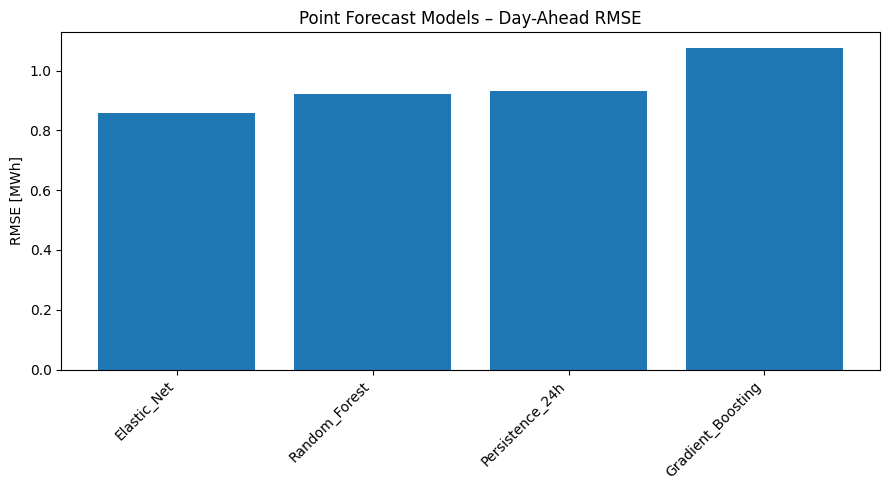

In [9]:
plot_df = point_metrics.sort_values("RMSE")

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE [MWh]")
plt.title("Point Forecast Models – Day-Ahead RMSE")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "point_forecast_rmse_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


# Teil B – Probabilistic Forecast Models

Probabilistische Modelle liefern mehrere Quantile pro Zeitpunkt.

Für das Newsvendor-Bidding ist das besonders relevant, weil je nach Kostenstruktur unterschiedliche Quantile als Gebot verwendet werden können.


## 10. Probabilistische Modelle trainieren

In [10]:
QUANTILES = (0.1, 0.25, 0.5, 0.75, 0.9)

prob_median_metrics_rows = []
pinball_rows = []

qr_models = quantile_regression.train(
    X_train,
    y_train,
    quantiles=QUANTILES,
)
qr_preds = quantile_regression.predict_all(qr_models, X_test)
y_pred_qr_q50 = qr_preds["q50"].to_numpy()

add_point_metrics(prob_median_metrics_rows, "Quantile_Regression_q50", y_test, y_pred_qr_q50)

qr_pinball = quantile_regression.evaluate_quantiles(y_test, qr_preds)
qr_pinball["model"] = "Quantile_Regression"
pinball_rows.append(qr_pinball)

qrf_model = quantile_regression_forest.train(
    X_train,
    y_train,
    n_estimators=300,
    min_samples_leaf=5,
)
qrf_preds = quantile_regression_forest.predict_all(
    qrf_model,
    X_test,
    quantiles=QUANTILES,
)
y_pred_qrf_q50 = qrf_preds["q50"].to_numpy()

add_point_metrics(prob_median_metrics_rows, "QRF_q50", y_test, y_pred_qrf_q50)

qrf_pinball = quantile_regression_forest.evaluate_quantiles(y_test, qrf_preds)
qrf_pinball["model"] = "QRF"
pinball_rows.append(qrf_pinball)

qgb_models = quantile_gradient_boosting.train(
    X_train,
    y_train,
    quantiles=QUANTILES,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=5,
)
qgb_preds = quantile_gradient_boosting.predict_all(qgb_models, X_test)
y_pred_qgb_q50 = qgb_preds["q50"].to_numpy()

add_point_metrics(prob_median_metrics_rows, "Quantile_Gradient_Boosting_q50", y_test, y_pred_qgb_q50)

qgb_pinball = quantile_gradient_boosting.evaluate_quantiles(y_test, qgb_preds)
qgb_pinball["model"] = "Quantile_Gradient_Boosting"
pinball_rows.append(qgb_pinball)

qnn_model = quantile_neural_network.train(
    X_train,
    y_train,
    quantiles=QUANTILES,
    hidden_layer_sizes=(64, 32),
    dropout=0.1,
    learning_rate=0.001,
    weight_decay=0.0001,
    batch_size=64,
    max_epochs=500,
    patience=30,
)
qnn_preds = quantile_neural_network.predict_all(qnn_model, X_test)
y_pred_qnn_q50 = qnn_preds["q50"].to_numpy()

add_point_metrics(prob_median_metrics_rows, "Quantile_Neural_Network_q50", y_test, y_pred_qnn_q50)

qnn_pinball = quantile_neural_network.evaluate_quantiles(y_test, qnn_preds)
qnn_pinball["model"] = "Quantile_Neural_Network"
pinball_rows.append(qnn_pinball)

prob_median_metrics = pd.DataFrame(prob_median_metrics_rows).sort_values("RMSE")
pinball_metrics = pd.concat(pinball_rows, ignore_index=True)
pinball_metrics = pinball_metrics[["model", "quantile", "pinball_loss"]]

prob_median_metrics


,model,MAE,RMSE,R2
3,Quantile_Neural_Network_q50,0.562916,0.909371,-0.135389
0,Quantile_Regression_q50,0.580903,0.944028,-0.223581
1,QRF_q50,0.634067,0.952667,-0.246077
2,Quantile_Gradient_Boosting_q50,0.653236,0.956030,-0.254890


## 11. Pinball Loss der probabilistischen Modelle

In [11]:
pinball_metrics.sort_values(["quantile", "pinball_loss"])


,model,quantile,pinball_loss
10,Quantile_Gradient_Boosting,0.10,0.061755
0,Quantile_Regression,0.10,0.061918
15,Quantile_Neural_Network,0.10,0.062640
5,QRF,0.10,0.078033
16,Quantile_Neural_Network,0.25,0.155648
1,Quantile_Regression,0.25,0.155939
11,Quantile_Gradient_Boosting,0.25,0.169130
6,QRF,0.25,0.187779
17,Quantile_Neural_Network,0.50,0.281458
2,Quantile_Regression,0.50,0.290451


## 12. Deskriptive Grafik: Pinball Loss

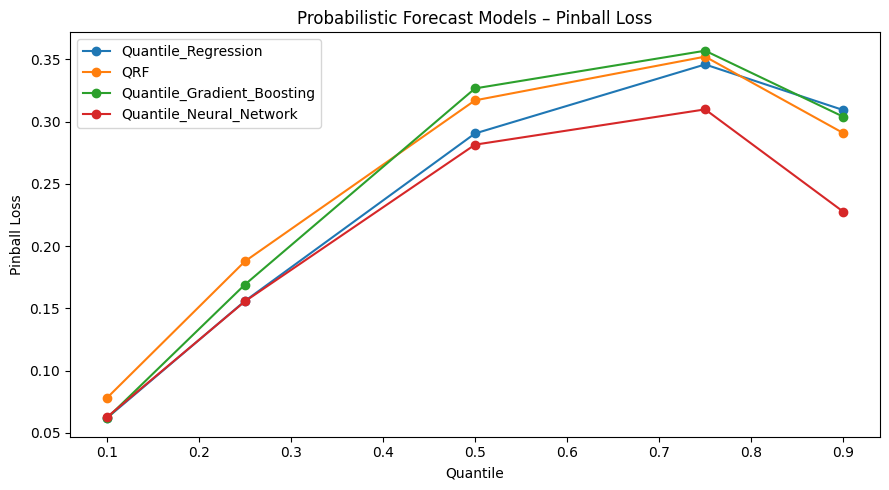

In [12]:
plt.figure(figsize=(9, 5))

for model_name in pinball_metrics["model"].unique():
    subset = pinball_metrics[pinball_metrics["model"] == model_name].sort_values("quantile")
    plt.plot(
        subset["quantile"],
        subset["pinball_loss"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Quantile")
plt.ylabel("Pinball Loss")
plt.title("Probabilistic Forecast Models – Pinball Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "probabilistic_pinball_loss_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Beispielgrafik: Quantile-Band

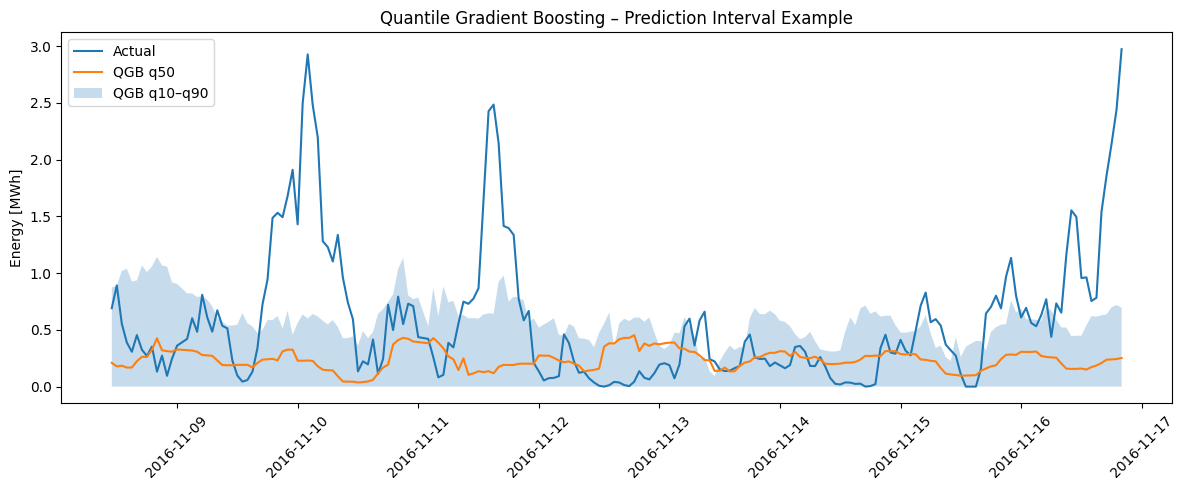

In [13]:
plot_window = min(200, len(y_test))

plot_data = pd.DataFrame({
    "timestamp": test_timestamps.iloc[:plot_window],
    "actual": y_test.iloc[:plot_window].to_numpy(),
    "q10": qgb_preds["q10"].iloc[:plot_window].to_numpy(),
    "q50": qgb_preds["q50"].iloc[:plot_window].to_numpy(),
    "q90": qgb_preds["q90"].iloc[:plot_window].to_numpy(),
})

plt.figure(figsize=(12, 5))
plt.plot(plot_data["timestamp"], plot_data["actual"], label="Actual")
plt.plot(plot_data["timestamp"], plot_data["q50"], label="QGB q50")
plt.fill_between(
    plot_data["timestamp"],
    plot_data["q10"],
    plot_data["q90"],
    alpha=0.25,
    label="QGB q10–q90",
)

plt.xticks(rotation=45)
plt.ylabel("Energy [MWh]")
plt.title("Quantile Gradient Boosting – Prediction Interval Example")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "qgb_prediction_interval_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


# Teil C – Gemeinsame Forecast Outputs

## 14. Gemeinsames Predictions-DataFrame erstellen

In [14]:
predictions = pd.DataFrame({
    "timestamp": test_timestamps.values,
    "y_true": y_test.to_numpy(),

    "persistence_24h": y_pred_persistence_24h,
    "elastic_net": y_pred_elastic_net,
    "random_forest": y_pred_random_forest,
    "gradient_boosting": y_pred_gradient_boosting,

    "quantile_regression_q10": qr_preds["q10"].to_numpy(),
    "quantile_regression_q25": qr_preds["q25"].to_numpy(),
    "quantile_regression_q50": qr_preds["q50"].to_numpy(),
    "quantile_regression_q75": qr_preds["q75"].to_numpy(),
    "quantile_regression_q90": qr_preds["q90"].to_numpy(),

    "qrf_q10": qrf_preds["q10"].to_numpy(),
    "qrf_q25": qrf_preds["q25"].to_numpy(),
    "qrf_q50": qrf_preds["q50"].to_numpy(),
    "qrf_q75": qrf_preds["q75"].to_numpy(),
    "qrf_q90": qrf_preds["q90"].to_numpy(),

    "qgb_q10": qgb_preds["q10"].to_numpy(),
    "qgb_q25": qgb_preds["q25"].to_numpy(),
    "qgb_q50": qgb_preds["q50"].to_numpy(),
    "qgb_q75": qgb_preds["q75"].to_numpy(),
    "qgb_q90": qgb_preds["q90"].to_numpy(),

    "qnn_q10": qnn_preds["q10"].to_numpy(),
    "qnn_q25": qnn_preds["q25"].to_numpy(),
    "qnn_q50": qnn_preds["q50"].to_numpy(),
    "qnn_q75": qnn_preds["q75"].to_numpy(),
    "qnn_q90": qnn_preds["q90"].to_numpy(),
})

print(predictions.shape)
predictions.head()


(1282, 26)


,timestamp,y_true,persistence_24h,elastic_net,random_forest,gradient_boosting,quantile_regression_q10,quantile_regression_q25,quantile_regression_q50,quantile_regression_q75,...,qgb_q10,qgb_q25,qgb_q50,qgb_q75,qgb_q90,qnn_q10,qnn_q25,qnn_q50,qnn_q75,qnn_q90
0,2016-11-08 11:00:00,0.691000,0.204000,0.378844,0.550077,0.387483,0.000459,0.019220,0.121133,0.507453,...,0.0,0.045175,0.209166,0.552852,0.874470,0.000000,0.046626,0.139566,0.357919,0.721249
1,2016-11-08 12:00:00,0.891500,0.163167,0.369516,0.571859,0.440756,0.000238,0.020119,0.126676,0.500573,...,0.0,0.027515,0.177686,0.582877,0.887587,0.009405,0.045151,0.140237,0.354500,0.729484
2,2016-11-08 13:00:00,0.553667,0.328833,0.384443,0.635096,0.454493,0.000542,0.027349,0.152061,0.554866,...,0.0,0.030744,0.184333,0.594136,1.020149,0.000217,0.046089,0.143744,0.369842,0.765838
3,2016-11-08 14:00:00,0.387833,0.030500,0.356833,0.610893,0.419966,0.000104,0.019665,0.123987,0.474217,...,0.0,0.034716,0.167829,0.623615,1.037672,0.000000,0.043410,0.140414,0.301876,0.718889
4,2016-11-08 15:00:00,0.306667,0.037000,0.362666,0.399496,0.341072,0.000330,0.023353,0.123172,0.433674,...,0.0,0.034716,0.167797,0.571106,0.926917,0.000000,0.048010,0.128213,0.261429,0.690694


## 15. Beispielgrafik: Actual vs. ausgewählte Forecasts

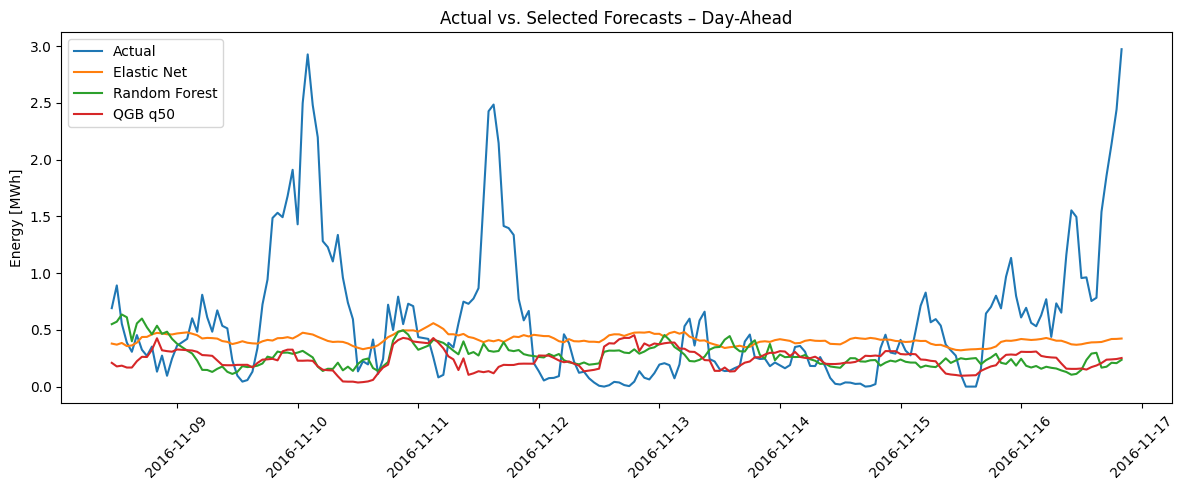

In [15]:
plot_window = min(200, len(predictions))

plt.figure(figsize=(12, 5))

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["y_true"].iloc[:plot_window],
    label="Actual",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["elastic_net"].iloc[:plot_window],
    label="Elastic Net",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["random_forest"].iloc[:plot_window],
    label="Random Forest",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["qgb_q50"].iloc[:plot_window],
    label="QGB q50",
)

plt.xticks(rotation=45)
plt.ylabel("Energy [MWh]")
plt.title("Actual vs. Selected Forecasts – Day-Ahead")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "actual_vs_selected_forecasts_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


## 16. Outputs speichern

In [16]:
predictions_path = FORECAST_DIR / "predictions_day_ahead.csv"
features_path = FORECAST_DIR / "test_features_day_ahead.csv"

point_metrics_path = TABLES_DIR / "point_forecast_metrics_day_ahead.csv"
prob_median_metrics_path = TABLES_DIR / "probabilistic_median_metrics_day_ahead.csv"
pinball_metrics_path = TABLES_DIR / "pinball_metrics_day_ahead.csv"

predictions.to_csv(predictions_path, index=False)
X_test.reset_index(drop=True).to_csv(features_path, index=False)

point_metrics.to_csv(point_metrics_path, index=False)
prob_median_metrics.to_csv(prob_median_metrics_path, index=False)
pinball_metrics.to_csv(pinball_metrics_path, index=False)

print("Saved:", predictions_path)
print("Saved:", features_path)
print("Saved:", point_metrics_path)
print("Saved:", prob_median_metrics_path)
print("Saved:", pinball_metrics_path)


Saved: /Users/noahweis/wind_bidding_project/results/forecasts/predictions_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/forecasts/test_features_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/tables/point_forecast_metrics_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/tables/probabilistic_median_metrics_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/tables/pinball_metrics_day_ahead.csv


## 17. Modelle speichern

In [17]:
joblib.dump(en_model, MODELS_DIR / "elastic_net_day_ahead.joblib")
joblib.dump(rf_model, MODELS_DIR / "random_forest_day_ahead.joblib")
joblib.dump(gb_model, MODELS_DIR / "gradient_boosting_day_ahead.joblib")

joblib.dump(qr_models, MODELS_DIR / "quantile_regression_day_ahead.joblib")
joblib.dump(qrf_model, MODELS_DIR / "qrf_day_ahead.joblib")
joblib.dump(qgb_models, MODELS_DIR / "quantile_gradient_boosting_day_ahead.joblib")
joblib.dump(qnn_model, MODELS_DIR / "quantile_neural_network_day_ahead.joblib")

print("Saved models to:", MODELS_DIR)


Saved models to: /Users/noahweis/wind_bidding_project/results/models


## 18. Zusammenfassung

In [18]:
print("Point Forecast Metrics")
display(point_metrics)

print("Probabilistic Median Metrics")
display(prob_median_metrics)

print("Pinball Metrics")
display(pinball_metrics.sort_values(["quantile", "pinball_loss"]))


Point Forecast Metrics


,model,MAE,RMSE,R2
1,Elastic_Net,0.583885,0.856551,-0.007324
2,Random_Forest,0.650673,0.920687,-0.163822
0,Persistence_24h,0.603841,0.931794,-0.192071
3,Gradient_Boosting,0.776294,1.074063,-0.583878


Probabilistic Median Metrics


,model,MAE,RMSE,R2
3,Quantile_Neural_Network_q50,0.562916,0.909371,-0.135389
0,Quantile_Regression_q50,0.580903,0.944028,-0.223581
1,QRF_q50,0.634067,0.952667,-0.246077
2,Quantile_Gradient_Boosting_q50,0.653236,0.956030,-0.254890


Pinball Metrics


,model,quantile,pinball_loss
10,Quantile_Gradient_Boosting,0.10,0.061755
0,Quantile_Regression,0.10,0.061918
15,Quantile_Neural_Network,0.10,0.062640
5,QRF,0.10,0.078033
16,Quantile_Neural_Network,0.25,0.155648
1,Quantile_Regression,0.25,0.155939
11,Quantile_Gradient_Boosting,0.25,0.169130
6,QRF,0.25,0.187779
17,Quantile_Neural_Network,0.50,0.281458
2,Quantile_Regression,0.50,0.290451
